In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("D:\\Fraud Detection model project 2\\Raw_dataset\\financial_fraud_detection_cleaned.csv")

print("dataset loaded successfully")
print("rows:", df.shape[0])
print("columns:", df.shape[1])

dataset loaded successfully
rows: 5000
columns: 14


In [5]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,NaN,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,NaN,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,NaN,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,NaN,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,NaN,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


In [6]:
df.tail()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
4995,T104995,CUST3702,NaN,182.15,Electronics,Debit Card,Mobile,Kolkata,0,13,277.99,840,No,0
4996,T104996,CUST6007,NaN,10.17,Fashion,Credit Card,Desktop,Chennai,0,128,477.24,441,No,0
4997,T104997,CUST6812,NaN,31.78,Grocery,Debit Card,Mobile,Kolkata,1,76,442.62,1474,No,1
4998,T104998,CUST9120,NaN,135.31,Utilities,Debit Card,Mobile,Bengaluru,0,13,73.33,246,No,0
4999,T104999,CUST1080,NaN,72.77,Entertainment,UPI,Mobile,Bengaluru,0,146,30.23,699,No,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         5000 non-null   str    
 1   Customer_ID            5000 non-null   str    
 2   Transaction_Date       0 non-null      float64
 3   Transaction_Amount     5000 non-null   float64
 4   Merchant_Category      5000 non-null   str    
 5   Payment_Method         5000 non-null   str    
 6   Device_Type            5000 non-null   str    
 7   Location               5000 non-null   str    
 8   Is_International       5000 non-null   int64  
 9   Previous_Transactions  5000 non-null   int64  
 10  Average_Spend          5000 non-null   float64
 11  Account_Age_Days       5000 non-null   int64  
 12  Suspicious_Keyword     5000 non-null   str    
 13  Fraudulent             5000 non-null   int64  
dtypes: float64(3), int64(4), str(7)
memory usage: 766.5 KB


In [8]:
# checking fraudulent variable in the dataset
df['Fraudulent'].value_counts()


Fraudulent
0    4518
1     482
Name: count, dtype: int64

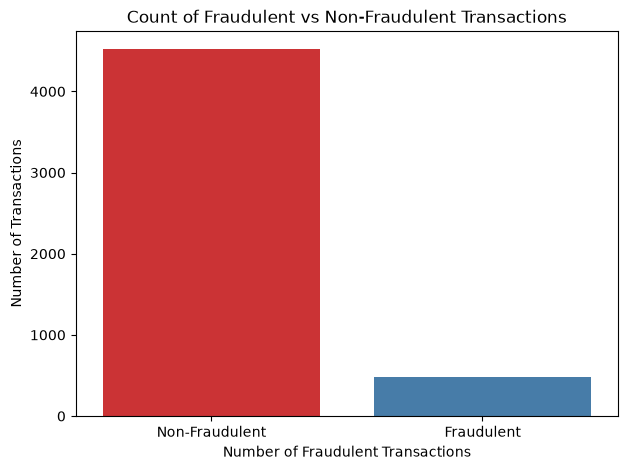

Count plot created successfully.


In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(x='Fraudulent', data=df, hue='Fraudulent', palette='Set1', legend=False)

plt.title('Count of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Number of Transactions')

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

print("Count plot created successfully.")


In [17]:
df["Transaction_Amount"].describe()

df.groupby("Fraudulent")["Transaction_Amount"].describe()



,count,mean,std,min,25%,50%,75%,max
Fraudulent,,,,,,,,
0,4518.0,78.880558,77.776372,0.0,22.635,55.455,110.3725,595.34
1,482.0,81.993693,89.373791,0.0,21.490,55.430,109.2900,653.80


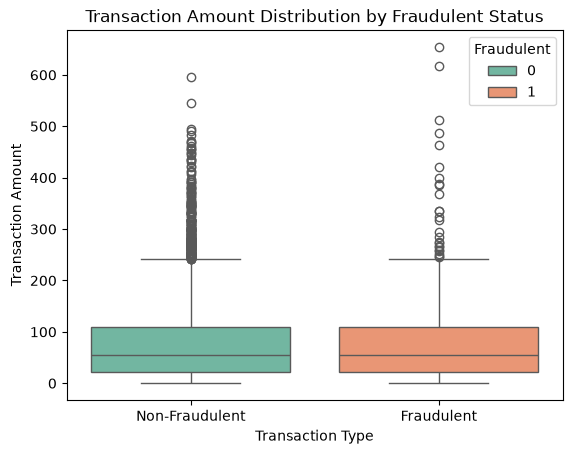

In [20]:
plt.Figure(figsize=(10, 6))

sns.boxplot( data=df, x='Fraudulent', y='Transaction_Amount', hue='Fraudulent', palette='Set2')

plt.title('Transaction Amount Distribution by Fraudulent Status')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])

plt.show()

In [21]:
# analyzing merchant category distribution for fraudulent and non-fraudulent transactions

df["Merchant_Category"].value_counts()

df.groupby("Fraudulent")["Merchant_Category"].value_counts()

Fraudulent  Merchant_Category
0           Food                 610
            Electronics          601
            Grocery              571
            Entertainment        558
            Fashion              546
            Health               545
            Utilities            544
            Travel               543
1           Food                  74
            Entertainment         72
            Fashion               62
            Health                61
            Grocery               58
            Travel                56
            Utilities             50
            Electronics           49
Name: count, dtype: int64

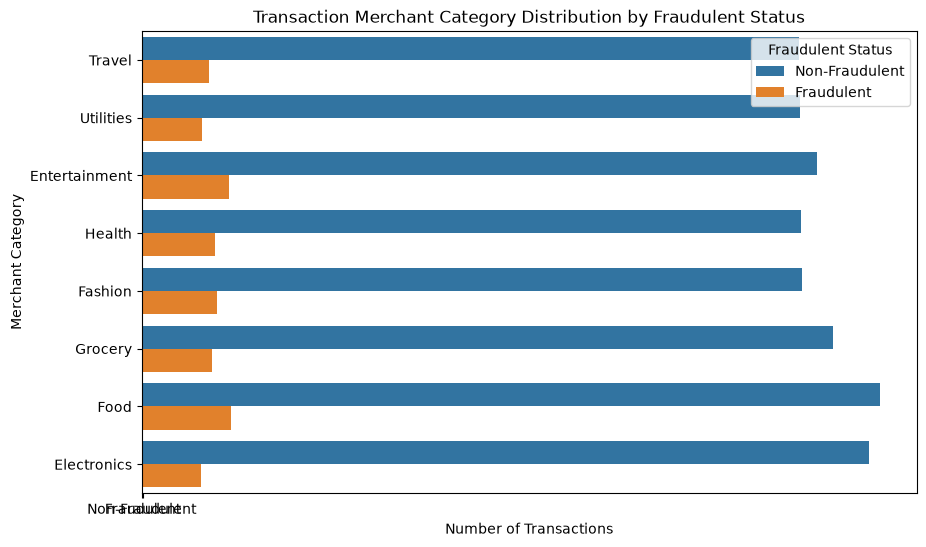

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Merchant_Category', hue='Fraudulent')

plt.title('Transaction Merchant Category Distribution by Fraudulent Status')   
plt.xlabel('Number of Transactions')
plt.ylabel('Merchant Category')

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])

plt.legend(title='Fraudulent Status', loc='upper right', labels=['Non-Fraudulent', 'Fraudulent'])

plt.show()


In [28]:
# Fraud rate by merchant category 
merchant_fraud_rate = df.groupby('Merchant_Category')['Fraudulent'].mean().sort_values(ascending=False)
merchant_fraud_rate


Merchant_Category
Entertainment    0.114286
Food             0.108187
Fashion          0.101974
Health           0.100660
Travel           0.093489
Grocery          0.092210
Utilities        0.084175
Electronics      0.075385
Name: Fraudulent, dtype: float64

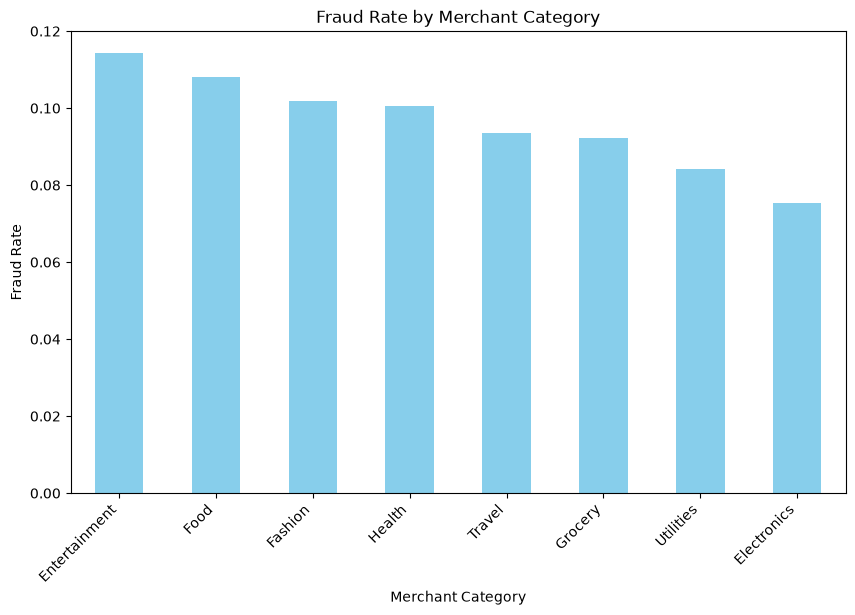

<Axes: xlabel='Fraudulent', ylabel='Transaction_Amount'>

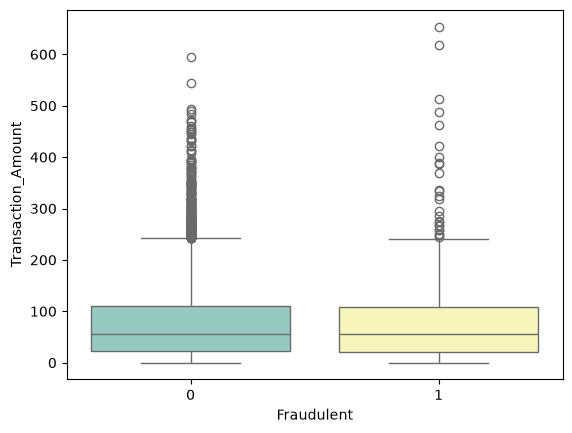

In [31]:
plt.figure(figsize=(10, 6))
merchant_fraud_rate.plot(kind='bar', color='skyblue')
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

sns.boxplot(data=df, x='Fraudulent', y='Transaction_Amount', hue='Fraudulent', palette='Set3', legend=False)

In [33]:
# payment analysis

df["Payment_Method"].value_counts()

Payment_Method
NetBanking     1037
PayPal         1022
Debit Card     1008
Credit Card     972
UPI             961
Name: count, dtype: int64

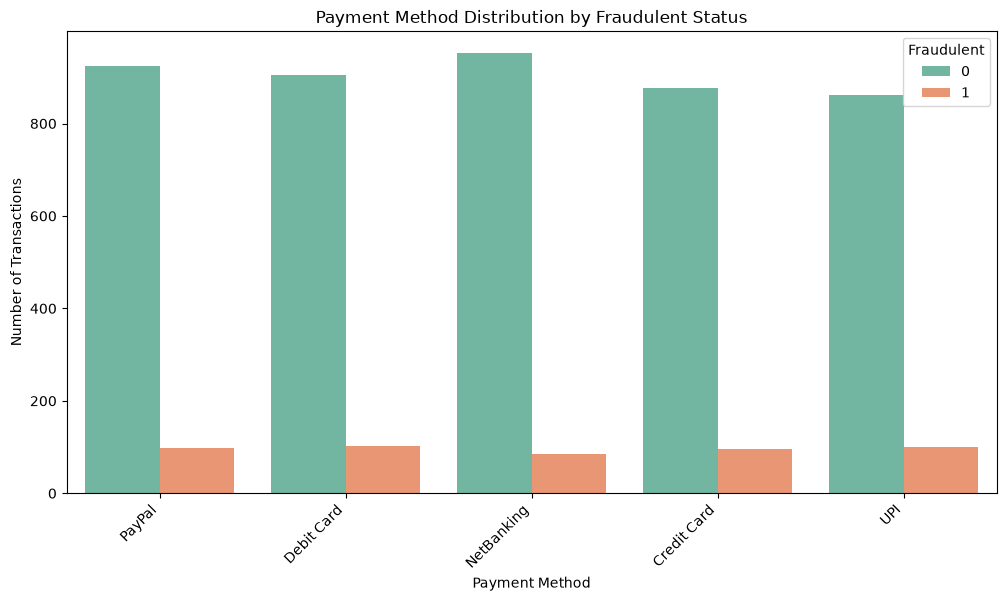

In [34]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Payment_Method', hue='Fraudulent', palette='Set2')    

plt.title('Payment Method Distribution by Fraudulent Status')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45, ha='right')
plt.show()  

In [35]:
# payment method by fraudrate

payment_fraud_rate = df.groupby('Payment_Method')['Fraudulent'].mean().sort_values(ascending=False)*100
payment_fraud_rate


Payment_Method
UPI            10.405827
Debit Card     10.218254
Credit Card     9.876543
PayPal          9.589041
NetBanking      8.196721
Name: Fraudulent, dtype: float64

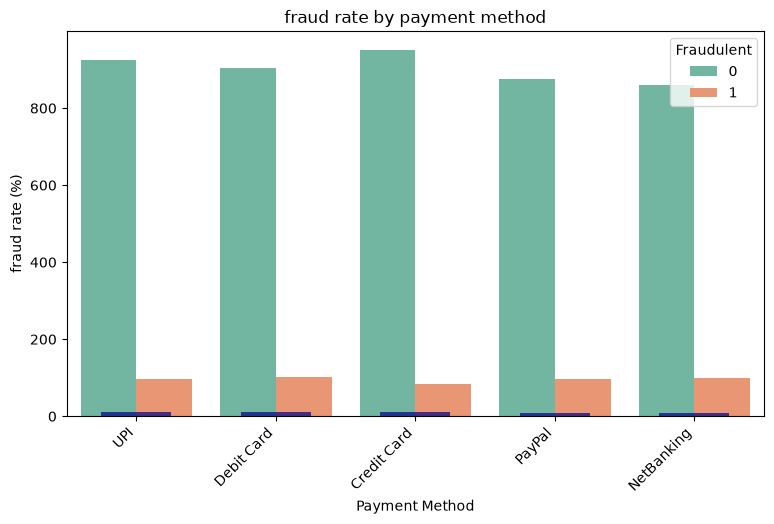

In [42]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Payment_Method', hue='Fraudulent', palette='Set2')

payment_fraud_rate.plot(kind='bar' , color='darkblue', alpha=0.7)

plt.title('fraud rate by payment method')
plt.xlabel('Payment Method')
plt.ylabel('fraud rate (%)')

plt.xticks(rotation=45, ha='right')
plt.show()

In [43]:
# device analysis

df["Device_Type"].value_counts()

Device_Type
Desktop    1679
POS        1673
Mobile     1648
Name: count, dtype: int64

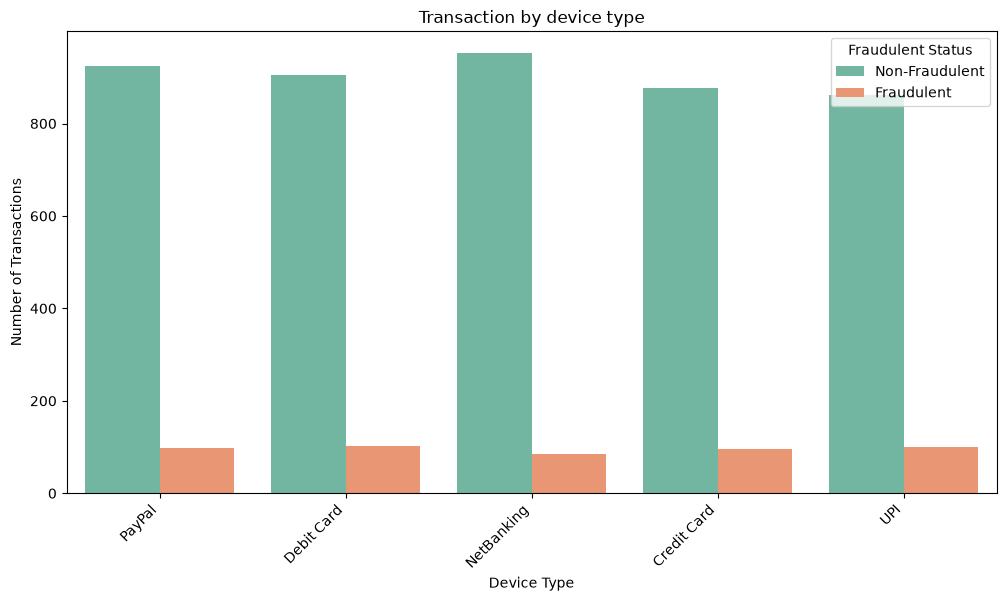

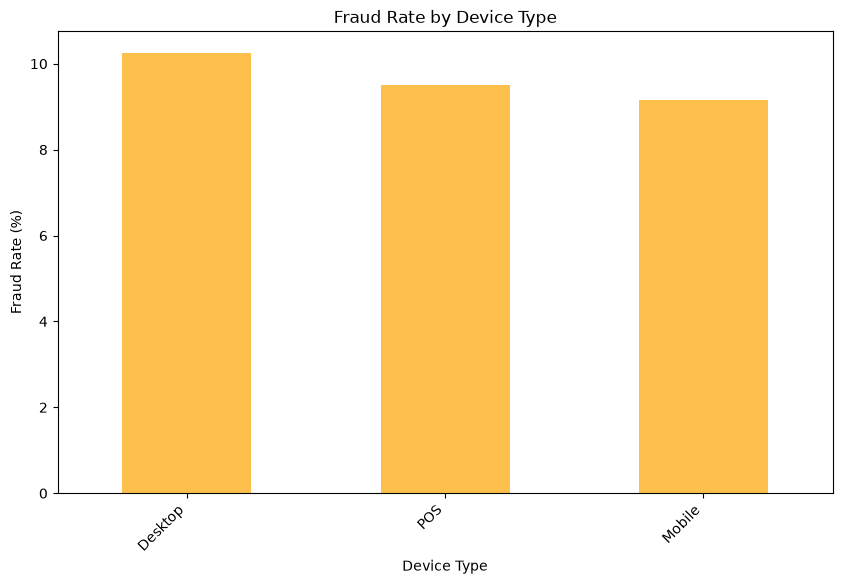

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Payment_Method', hue='Fraudulent', palette='Set2') 

plt.title('Transaction by device type')
plt.xlabel('Device Type')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Fraudulent Status', loc='upper right', labels=['Non-Fraudulent', 'Fraudulent'])

plt.show()


# analyzing device fraud-rate

device_fraud_rate = (
    df.groupby("Device_Type")["Fraudulent"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

device_fraud_rate

plt.figure(figsize=(10, 6))
device_fraud_rate.plot(kind="bar", color="orange", alpha=0.7)

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45, ha="right")
plt.show()

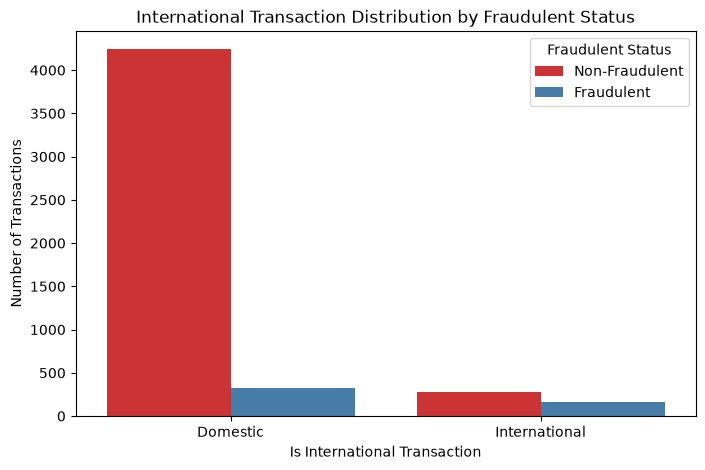

Is_International
1    36.961451
0     6.997148
Name: Fraudulent, dtype: float64

In [ ]:
# internationa transaction analysis

df["Is_International"].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Is_International', hue='Fraudulent', palette='Set1')


plt.title('International Transaction Distribution by Fraudulent Status')
plt.xlabel('Is International Transaction')
plt.ylabel('Number of Transactions')

plt.xticks(ticks=[0, 1], labels=['Domestic', 'International'])
plt.legend(title='Fraudulent Status', loc='upper right', labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

international_fraud_rate = (
    df.groupby("Is_International")["Fraudulent"].mean().sort_values(ascending=False)* 100)
international_fraud_rate

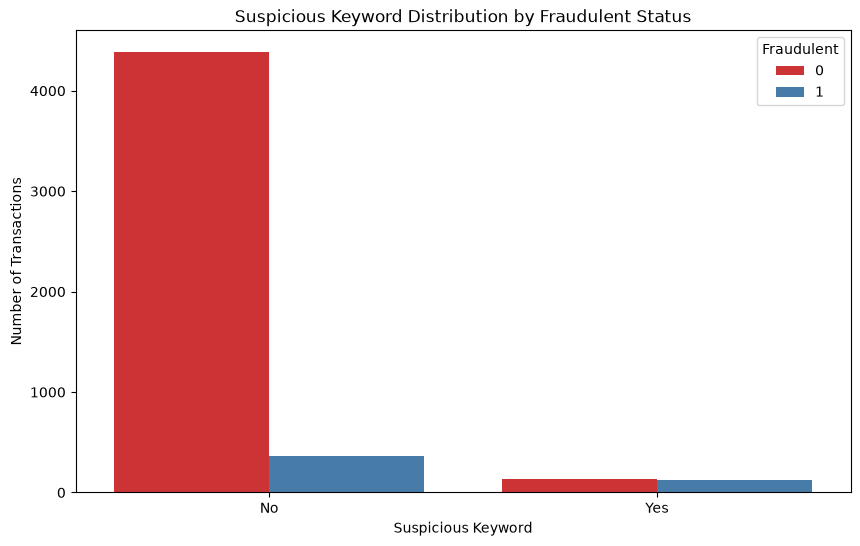

In [74]:
# suspicious analysis

df["Suspicious_Keyword"].value_counts()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Suspicious_Keyword', hue='Fraudulent', palette='Set1')

plt.title('Suspicious Keyword Distribution by Fraudulent Status')
plt.xlabel('Suspicious Keyword')    
plt.ylabel('Number of Transactions')
plt.legend(title='Fraudulent')

plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()